# Test 2: Block-drop AUC

Question: **Which immune compartments are necessary for HIV classification when the rest of the profile remains available?**

This is a different question from block-only AUC. A block can be weak alone but still necessary if removing it disrupts a cross-block pattern.

In [1]:
from pathlib import Path
import os
if (Path.cwd() / 'data_synthesis' / 'notebooks').exists():
    os.chdir(Path.cwd() / 'data_synthesis' / 'notebooks')
%run ./00_block_auc_common.ipynb


C:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Loaded HIV matrix: 91 participants x 63 features; class counts HIV-=23, PLWH=68


## Drop tests in this notebook

Primary block-drop test:

- all features except serum IgG
- all features except production/decay
- all features except ACE2

These are the three most paper-relevant removals because they distinguish static antibody trajectories, derived dynamic summaries, and neutralization-related structure.

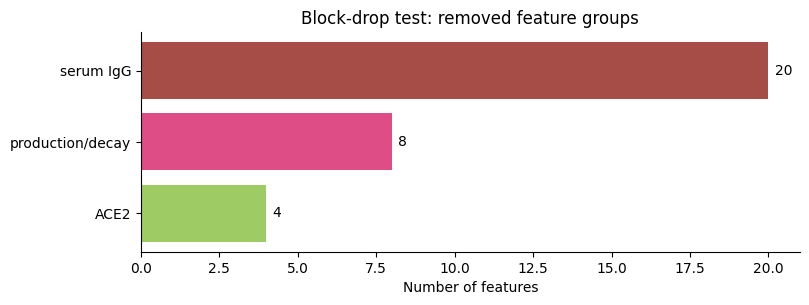

**serum IgG** (20): V1_blood_IgGspike, V4_blood_IgGspike, V4a_blood_IgGspike, V6_blood_IgGspike, V8_blood_IgGspike, V8a_blood_IgGspike, V8b_blood_IgGspike, V9_blood_IgGspike, V10_blood_IgGspike, V11_blood_IgGspike, V1_blood_IgGRBD, V4_blood_IgGRBD, V4a_blood_IgGRBD, V6_blood_IgGRBD, V8_blood_IgGRBD, V8a_blood_IgGRBD, V8b_blood_IgGRBD, V9_blood_IgGRBD, V10_blood_IgGRBD, V11_blood_IgGRBD

**production/decay** (8): spikeProduction_D1D2, spikeDecay_D1D2, spikeProduction_D3, spikeDecay_D3, RBDProduction_D1D2, RBDDecay_D1D2, RBDProduction_D3, RBDDecay_D3

**ACE2** (4): V7_ACE2, V8_ACE2, V8b_ACE2, V9_ACE2

In [2]:
DROP_BLOCKS = PRIMARY_BLOCK_DROP
plot_block_definitions(DROP_BLOCKS, title='Block-drop test: removed feature groups')
show_block_members(DROP_BLOCKS)


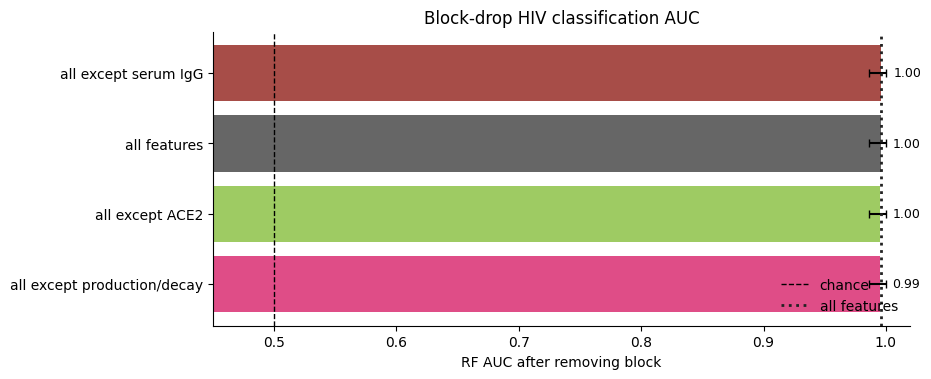

In [3]:
block_drop_auc, full_auc = evaluate_block_drop(DROP_BLOCKS)
plot_auc_bars(
    block_drop_auc,
    title='Block-drop HIV classification AUC',
    xlabel='RF AUC after removing block',
    baseline=full_auc['mean'],
)


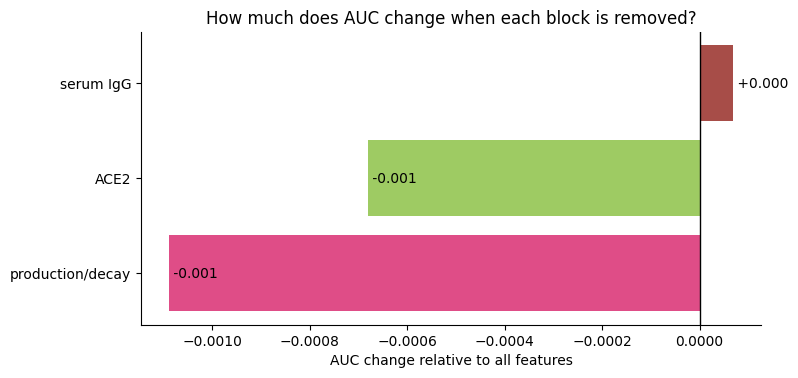

In [4]:
delta_df = block_drop_auc[block_drop_auc['block'] != 'all features'].copy()
delta_df = delta_df.sort_values('delta_from_full')
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [BLOCK_COLORS.get(b, '#555555') for b in delta_df['dropped_block']]
ax.barh(delta_df['dropped_block'], delta_df['delta_from_full'], color=colors, alpha=0.9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('AUC change relative to all features')
ax.set_title('How much does AUC change when each block is removed?')
ax.spines[['top', 'right']].set_visible(False)
for y_i, (_, row) in enumerate(delta_df.iterrows()):
    ax.text(row['delta_from_full'], y_i, f" {row['delta_from_full']:+.3f}", va='center')
plt.show()


## How to read this plot

A negative AUC change means the removed block was useful or necessary. A near-zero change means the remaining feature profile can compensate. A positive change can happen in small cohorts if a noisy or redundant block hurts generalization.